In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [2]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor = 0.1, noise = 0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

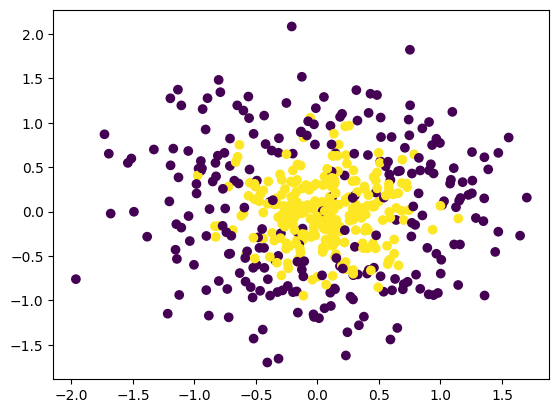

In [3]:
plt.scatter(X[:,0], X[:,1], c=y)

In [4]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

abc = AdaBoostClassifier()

np.mean(cross_val_score(abc, X, y, scoring='accuracy', cv = 10))

np.float64(0.812)

In [5]:
abc.fit(X, y)

AdaBoostClassifier()

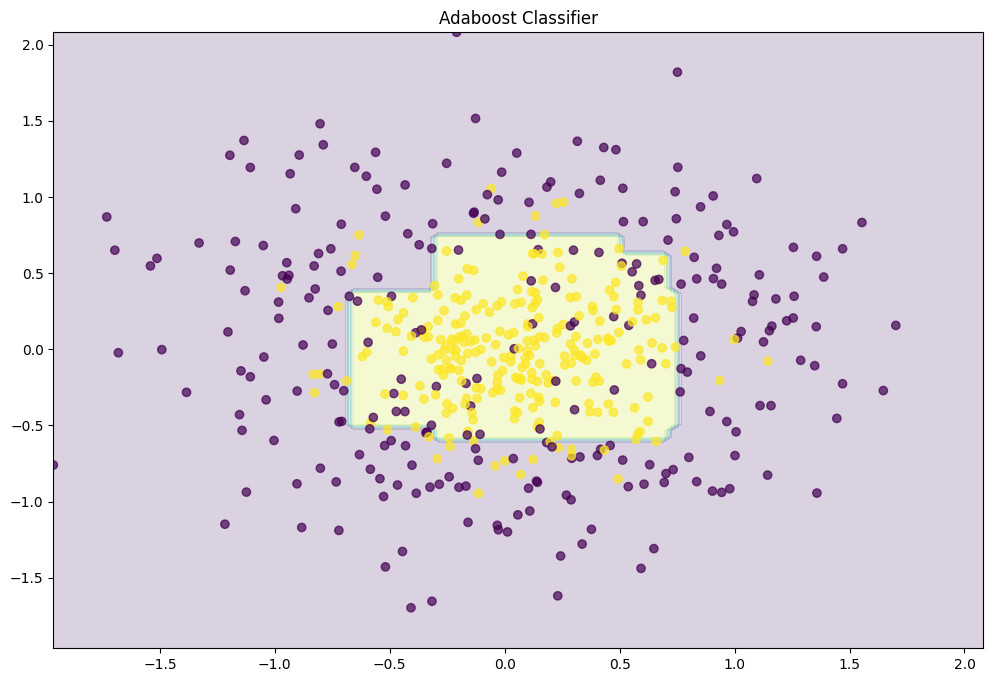

In [8]:
def plot_decision_boundary(clf):
  plt.figure(figsize=(12, 8))
  x_range = np.linspace(X.min(), X.max(), 100)
  xx1, xx2 = np.meshgrid(x_range, x_range)
  y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
  y_hat = y_hat.reshape(xx1.shape)
  plt.contourf(xx1, xx2, y_hat, alpha=0.2)
  plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
  plt.title('Adaboost Classifier')
  plt.show()
plot_decision_boundary(abc)

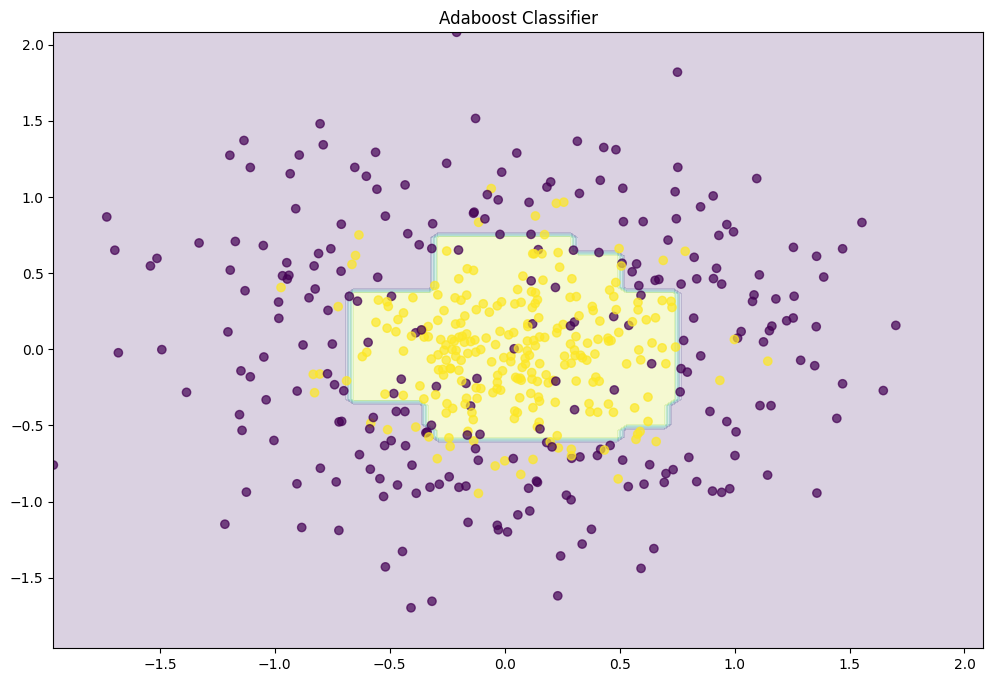

In [22]:
abc = AdaBoostClassifier(n_estimators=500)
abc.fit(X,y)
plot_decision_boundary(abc)

### GridSearchCV

In [23]:
from sklearn.model_selection import GridSearchCV

n_estimators = [10, 50, 100, 500]
learning_rate = [0.0001, 0.001, 0.01, 0.1, 1.0]
algorithm = ['SAMME', 'SAMME.R']

param_grid = {
    'n_estimators' : n_estimators,
    'learning_rate' : learning_rate,
    'algorithm' : algorithm
}

In [24]:
grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(),
    param_grid=param_grid,
    n_jobs=-1,
    cv=10,
    scoring='accuracy')

In [25]:
grid_result = grid_search.fit(X, y)
print(grid_result.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
200 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
200 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

{'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 500}


In [26]:
grid_result.best_score_

np.float64(0.8320000000000001)